In [1]:
# Import standard library and packages
import os
import numpy as np
import torch
import pandas
import matplotlib.pyplot as plt
import math
import re

In [2]:
# Import the necessary scripts
from MulticlassClassification import MulticlassClassification
from FakeNewsDataset import FakeNewsDataset
from CollateFunction import collate_fn
import DataProcessing as DP
import FCNModelAnalysis as FMA

In [3]:
_CURRENTDIR = os.path.abspath('')
true_path = _CURRENTDIR + '/True.csv'
fake_path = _CURRENTDIR + '/Fake.csv'

In [4]:
true_df = pandas.read_csv(true_path).dropna()
fake_df = pandas.read_csv(fake_path).dropna()

In [6]:
# true_df.text = true_df.text.str.replace(r"[^A-Za-z0-9\s\.]", '', regex=True)
true_df = true_df.replace(r"[^A-Za-z0-9\s\.]", '', regex=True)

In [7]:
true_df

,title,text,subject,date
0,As U.S. budget fight looms Republicans flip th...,WASHINGTON Reuters The head of a conservative...,politicsNews,December 31 2017
1,U.S. military to accept transgender recruits o...,WASHINGTON Reuters Transgender people will be...,politicsNews,December 29 2017
2,Senior U.S. Republican senator Let Mr. Mueller...,WASHINGTON Reuters The special counsel invest...,politicsNews,December 31 2017
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON Reuters Trump campaign adviser Geo...,politicsNews,December 30 2017
4,Trump wants Postal Service to charge much more...,SEATTLEWASHINGTON Reuters President Donald Tr...,politicsNews,December 29 2017
...,...,...,...,...
21412,Fully committed NATO backs new U.S. approach o...,BRUSSELS Reuters NATO allies on Tuesday welco...,worldnews,August 22 2017
21413,LexisNexis withdrew two products from Chinese ...,LONDON Reuters LexisNexis a provider of legal...,worldnews,August 22 2017
21414,Minsk cultural hub becomes haven from authorities,MINSK Reuters In the shadow of disused Soviet...,worldnews,August 22 2017
21415,Vatican upbeat on possibility of Pope Francis ...,MOSCOW Reuters Vatican Secretary of State Car...,worldnews,August 22 2017


In [8]:
Xtrue = np.array(true_df['title'] + ' ' + true_df['text'] + ' ' + true_df['subject'])
Ttrue = np.array(['True'] * len(Xtrue))
Xfake = np.array(fake_df['title'] + ' ' + fake_df['text'] + ' ' + fake_df['subject'])
Tfake = np.array(['Fake'] * len(Xfake))

In [9]:
n_test_half = int(len(Xtrue) * 0.1)
Xtest = np.concatenate((Xtrue[:n_test_half, ...], Xfake[:n_test_half, ...]))
Ttest = np.concatenate((Ttrue[:n_test_half], Tfake[:n_test_half]))

Xdata = np.concatenate((Xtrue[n_test_half:, ...], Xfake[n_test_half:, ...]))
Tdata = np.concatenate((Ttrue[n_test_half:], Tfake[n_test_half:]))

In [10]:
test_indices = list(range(len(Xtest)))
train_indices = list(range(len(Xdata)))
np.random.shuffle(test_indices)
np.random.shuffle(train_indices)

Xdata = Xdata[train_indices[:1000], ...] #1000, 256
Tdata = Tdata[train_indices[:1000]] #1000, 256
Xtest = Xtest[test_indices[:500], ...] #500, 256
Ttest = Ttest[test_indices[:500]] #500, 256

In [11]:
train_data, valid_data = DP.split_data(Xdata, Tdata)
test_data = (Xtest, Ttest)

In [12]:
vocab_list = list(set(np.concatenate([x.split() for x in Xdata])))
special_chars = ['<unk>']
vocab_list = vocab_list + special_chars
vocab_dict = {w: i+1 for i, w in enumerate(vocab_list)}
vocab_dict['<pad>'] = 0
vocab_dict_reverse = {v: k for k, v in vocab_dict.items()}

In [13]:
len(vocab_dict)

45249

In [14]:
# Size of train, validation, and test set
len(train_data[0]), len(valid_data[0]), len(test_data[0])

(800, 200, 500)

In [15]:
use_gpu = True

classes = np.unique(Tdata)
pad_idx = vocab_dict['<pad>']
max_len = max([len(x.split()) for x in Xdata])

split_tuples_list = [train_data, valid_data, test_data]

dataset_list = [FakeNewsDataset(stup, vocab_dict, max_len, pad_idx, classes) for stup in split_tuples_list]

batch_size_list = [128, 128, 128] if use_gpu else [32, 32, 32]  # [10, 10, 10], [512, 512, 512]
shuffle_list = [True, False, False]

trainloader, validloader, testloader = (torch.utils.data.DataLoader(dataset, 
                                                                    batch_size = batch_size, 
                                                                    collate_fn = collate_fn, 
                                                                    shuffle = shuffle) 
                                        for dataset, batch_size, shuffle 
                                        in zip(dataset_list, batch_size_list, shuffle_list))

In [13]:
preds_list = []
confs_list = []
evaluation_res_list = []

train_error_list = []
train_error_trace_list = []

valid_error_list = []
valid_error_trace_list = []

#max_len = 

#rnn_arch_list = [(hidden_size, num_layers, nonlinearity), (...)]

text_params_list = [{'max_len': max_len, 
                     'vocab_size': len(vocab_dict), 
                     'input_size': 300, 
                     'pad': pad_idx, 
                     'algo': 'rnn', 
                     'rnn_arch_list': [(256, 1, 'relu')], 
                     'batch_first': True, 
                     'bidirectional': False,
                     'n_units_in_fc_layers': []
                    }, 
                    {'max_len': max_len, 
                     'vocab_size': len(vocab_dict), 
                     'input_size': 20, 
                     'pad': pad_idx,  #0
                     'algo': 'rnn', 
                     'rnn_arch_list': [(10, 2, 'tanh'), (10, 1, 'tanh')], 
                     'batch_first': True, 
                     'bidirectional': True,
                     'n_units_in_fc_layers': [2]
                    }, 
                    {'max_len': max_len, 
                     'vocab_size': len(vocab_dict), 
                     'input_size': 20, 
                     'pad': pad_idx,  #0
                     'algo': 'rnn',  
                     'rnn_arch_list': [(10, 2, 'tanh')], 
                     'batch_first': True, 
                     'bidirectional': True,
                     'n_units_in_fc_layers': [10]
                    }]

#classes = np.array(range(2))
data_type = 'text'
use_gpu = True

lr_list = [0.001, 0.01, 0.01]
n_epochs_list = [3, 2, 3]

best_vloss = None
states_path = './saved_states/fakenews_model_states.pth'

for text_params, learning_rate, n_epochs in zip(text_params_list, lr_list, n_epochs_list):

    print('Exp')#, end = ' ')

    multc_model = MulticlassClassification(data_type, text_params, classes, use_gpu)
    multc_model.train(trainloader, validloader, learning_rate, n_epochs, best_vloss, states_path = states_path)
    best_vloss = multc_model.get_best_validation_loss()
    
    train_error_trace, valid_error_trace = multc_model.get_error_trace()
    train_error_trace_list.append(train_error_trace)
    valid_error_trace_list.append(valid_error_trace)
    
    train_error = train_error_trace[-1]
    train_error_list.append(train_error)
    
    valid_error = valid_error_trace[-1]
    valid_error_list.append(valid_error)
    
    Y_preds, Y_confs = multc_model.predict(testloader)
    confs_list.append(Y_confs)
    preds_list.append(Y_preds)
    evaluation_res_list.append(multc_model.evaluate(testloader))
    print("\n")

Exp
0 | | 
1 | | 
2 | | 


Exp
0 | | 
1 | | 


Exp
0 | | 
1 | | 
2 | | 




In [14]:
pandas.set_option('display.max_colwidth', None)
pandas.DataFrame([text_params_list, n_epochs_list, lr_list, train_error_list, valid_error_list, evaluation_res_list], 
                 index = ['Model Arch', 'Epochs', 'lr', 'Tr-loss', 'Val-loss', 'Test-Acc']).T

,Model Arch,Epochs,lr,Tr-loss,Val-loss,Test-Acc
0,"{'max_len': 2868, 'vocab_size': 19874, 'input_size': 300, 'pad': 0, 'algo': 'rnn', 'rnn_arch_list': [(256, 1, 'relu')], 'batch_first': True, 'bidirectional': False, 'n_units_in_fc_layers': []}",3,0.001,0.674288,0.712916,0.503906
1,"{'max_len': 2868, 'vocab_size': 19874, 'input_size': 20, 'pad': 0, 'algo': 'rnn', 'rnn_arch_list': [(10, 2, 'tanh'), (10, 1, 'tanh')], 'batch_first': True, 'bidirectional': True, 'n_units_in_fc_layers': [2]}",2,0.01,0.765586,0.713276,0.496094
2,"{'max_len': 2868, 'vocab_size': 19874, 'input_size': 20, 'pad': 0, 'algo': 'rnn', 'rnn_arch_list': [(10, 2, 'tanh')], 'batch_first': True, 'bidirectional': True, 'n_units_in_fc_layers': [10]}",3,0.01,0.678758,0.730255,0.503906


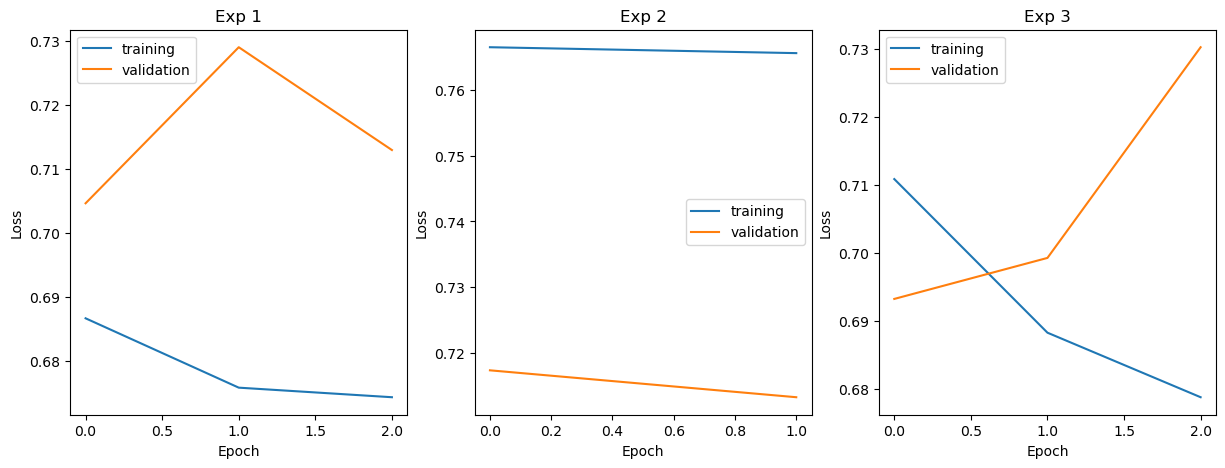

In [15]:
plt.figure(figsize = (20, 5))
n = len(n_epochs_list)
col = 4 #int(n/4)
row = math.ceil(n/col)
for i in range(n):
    plt.subplot(row, col, i+1)
    plt.plot(train_error_trace_list[i], label = 'training')
    plt.plot(valid_error_trace_list[i], label = 'validation')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title(f'Exp {i+1}')

In [16]:
# Best trained model's result

checkpoint = torch.load(states_path) #('model_states.pth')

multc_model_resume = MulticlassClassification(*checkpoint['model_args'])

multc_model_resume.nnet_model.load_state_dict(checkpoint['model_state_dict'])
Y_pred, Y_conf = multc_model_resume.predict(testloader) 
eval_result = multc_model_resume.evaluate(testloader)
print(eval_result)

0.50390625


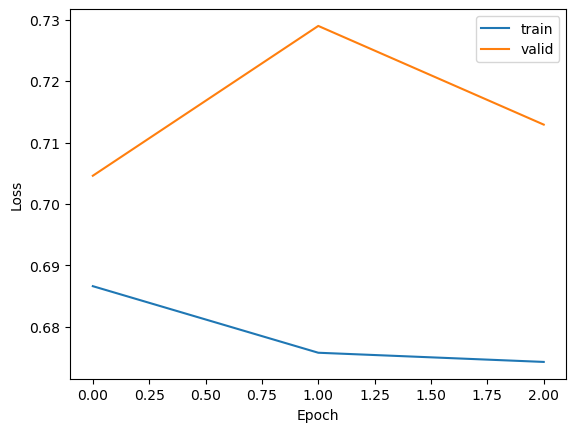

In [17]:
i = 0
plt.plot(train_error_trace_list[i], label = 'train')
plt.plot(valid_error_trace_list[i], label = 'valid')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend();

In [18]:
# Choose the network with better result, change anything needed, and train longer.

states_path = './saved_states/fakenews_model_states.pth'

checkpoint = torch.load(states_path)
#best_idx = np.argmax(evaluation_res_list)
best_args = checkpoint['model_args']
n_epochs = checkpoint['epoch']
#learning_rate = checkpoint['learning_rate']
loss_F = checkpoint['loss']

data_type, text_params, classes, use_gpu = best_args
#data_type = 'text'

learning_rate = 0.0001
n_epochs = 10

text_params = {'max_len': max_len, 
               'vocab_size': len(vocab_dict), 
               'input_size': 16 #32,#300, 
               'pad': pad_idx, 
               'algo': 'gru', 
               'rnn_arch_list': [(16, 1, 'relu')] # [(32, 1, 'relu')], # [(256, 1, 'relu')], 
               'batch_first': True, 
               'bidirectional': False, 
               'n_units_in_fc_layers': [] # 30
              }

# Specify a new path for saving the states of this trial.
best_vloss = None
states_path = './saved_states/fakenews_model_states_trial.pth'

multc_model = MulticlassClassification(data_type, text_params, classes, use_gpu)
    
# Now either load the trained model's states and retrain (uncomment the following line)
#multc_model.nnet_model.load_state_dict(checkpoint['model_state_dict'])

multc_model.train(trainloader, validloader, learning_rate, n_epochs, best_vloss, states_path = states_path)
best_vloss = multc_model.get_best_validation_loss()
print(f'Best validation loss: {best_vloss:.3f}')

train_error_trace, valid_error_trace = multc_model.get_error_trace()

Y_preds, Y_confs = multc_model.predict(testloader)
Test_acc = multc_model.evaluate(testloader)
print(f'Test Accuracy: {Test_acc:.3f}')

0 | | 
1 | | 
2 | | 
3 | | 
4 | | 
5 | | 
6 | | 
7 | | 
8 | | 
9 | | 
Best validation loss: 0.695
Test Accuracy: 0.496


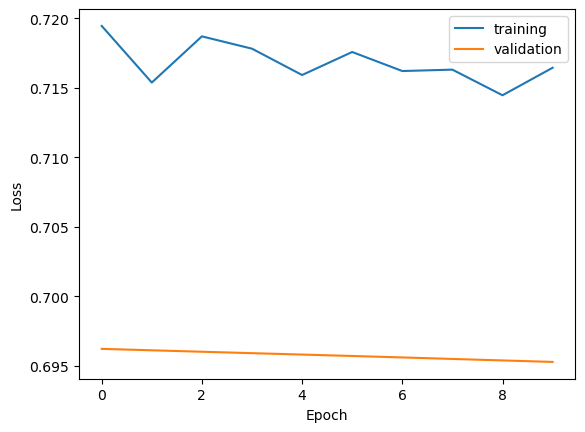

In [20]:
# Loss vs Epoch plot of the above trained model.

plt.plot(train_error_trace, label = 'training')
plt.plot(valid_error_trace, label = 'validation')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend();

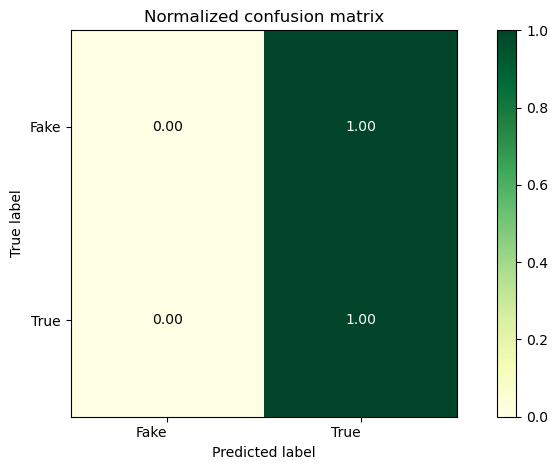

In [21]:
# Add confusion matrix on test set

Pte, Prte = multc_model.predict(testloader) #nnet.use(Xtenn)
np.set_printoptions(precision=2)

# Plot normalized confusion matrix
FMA.plot_confusion_matrix(Ttest, Pte, classes=np.unique(Ttest),
                      title='Normalized confusion matrix')

plt.show()

In [ ]:
# Do some plotting (Multilabel CM, learning curve, weights visualization, CM, ROC) and add brief description.

In [37]:
# Use the preferred trained model to test on a different set of samples (rerun the dataloader cell to get a different set).
# Use either './saved_states/fakenews_model_states.pth' or './saved_states/fakenews_model_states_trial.pth'

reuse_states_path = './saved_states/fakenews_model_states_trial.pth'
checkpoint = torch.load(reuse_states_path) 

multc_model_reload = MulticlassClassification(*checkpoint['model_args'])

multc_model_reload.nnet_model.load_state_dict(checkpoint['model_state_dict'])
Y_pred, Y_conf = multc_model_reload.predict(testloader) 
eval_result = multc_model_reload.evaluate(testloader)
print(f'{eval_result:.4f}')

0.5080


In [20]:
# Inspect visually the samples and their prediction (on top of each plot) by the model.
# Fix this to add some plots to visualize wrongly predicted samples and correctly predicted samples. (or maybe the statistics of them?)
# implement numpy array of test sample input in the model.

# Get first batch of testloader for some examples.
for batch in testloader:
    Xset = batch['features'].numpy()
    Tset = batch['targets'].numpy().astype('int')
    break
    
#plt.figure(figsize = (16, 10))
row = 5
col = 2
total = int(row * col)
rand_ind = np.random.randint(0, len(Xset), total)
for i in range(total):
    #plt.subplot(row, col, i+1)
    sample = Xset[rand_ind[i]]
    print(' '.join([vocab_dict_reverse[j] for j in sample[:40] if j != 0]))
    print(f'Actual: {classes[Tset[rand_ind[i]]].item()}')
    Y_pred, Y_conf = multc_model.predict(sample.reshape(1, -1))
    print(f'Predicted: {Y_pred}')
    print(f'Confidence: {Y_conf.item():.4f}')
    print('\n');
    #plt.imshow(img)
    #plt.title(label = infer_Y_pred[rand_ind[i]])
    #plt.axis('off');

Judge Who Barred A Mom From Seeing Her Baby For A Year Over Unpaid Fees Resigns With all the recent talk of sentencing reform and unfair bail across America, sometimes what it takes is an outrageous case in a small
Actual: Fake
Predicted: Fake
Confidence: 0.5283


GOP Senator Just Smacked Down The Most <unk> Alt-Right Nazi On The Internet The most punchable Alt-Right Nazi on the internet just got a thorough beatdown from Sen. Ben Sasse (R-Neb.) on Twitter during an epic <unk> Richard Spencer, the
Actual: Fake
Predicted: Fake
Confidence: 0.5283


Factbox: Key Republicans in U.S. Senate tax bill fight WASHINGTON (Reuters) - Six more U.S. senators signed on to support a sweeping Republican tax bill on Friday, leaving only one known Republican opponent - Bob Corker - and virtually assuring
Actual: True
Predicted: Fake
Confidence: 0.5283


Top Trump Advisor Exposed As Member Of Nazi Group – AND He Violated Immigration Laws: Report Funny how this just keeps <unk> another Trump advisor has be